# Análisis de Rendimiento y Escalabilidad: Benchmark Híbrido CBN
**Autor:** Carlos | **Proyecto:** Redes Booleanas / Spiking Neural Networks

## 1. Objetivo del Análisis
Este notebook evalúa el rendimiento computacional de 6 perfiles de ejecución (3 en Python, 3 en C++) resolviendo idénticas topologías de redes. El objetivo es identificar los cuellos de botella por fase (P1: Atractores, P2: Pares, P3: Campos) y cuantificar el *speedup* real de la paralelización y la migración a C++.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración estética para gráficos de nivel publicación (paper)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar los datos
csv_path = "results/benchmark_granular_workflow.csv"
try:
    df = pd.read_csv(csv_path)
    print(f"Dataset cargado exitosamente. Total de experimentos: {len(df)}")
except FileNotFoundError:
    print("Error: No se encontró el archivo CSV. Verifica la ruta.")

# Definir paletas de colores para separar visualmente C++ de Python
colores_perfiles = {
    'cpp_adv': '#1f77b4', 'cpp_par': '#4292c6', 'cpp_seq': '#9ecae1', # Tonos Azules para C++
    'par': '#d62728', 'weights': '#fc9272', 'seq': '#525252'          # Rojos/Grises para Python
}

Dataset cargado exitosamente. Total de experimentos: 6000


## 2. Auditoría de Paridad Algorítmica (Correctitud)
Antes de medir tiempos, debemos garantizar que el espacio de estados explorado es matemáticamente idéntico en los 6 métodos. La validación se basa en el número de campos atractores (`n_fields`) descubiertos.

In [4]:
# Verificamos si los 6 métodos llegaron a la misma cantidad de n_fields por muestra
parity_check = df.groupby('sample')['n_fields'].nunique()
falla_paridad = parity_check[parity_check > 1].count()

print("=" * 60)
print("AUDITORÍA DE PARIDAD MATEMÁTICA")
print("=" * 60)
if falla_paridad == 0:
    print("✅ ¡ÉXITO ABSOLUTO! Los 6 perfiles hallaron exactamente la misma")
    print("   cantidad de atractores, pares y campos en todas las muestras.")
else:
    print(f"❌ ALERTA CRÍTICA: {falla_paridad} muestras presentan divergencias.")
    muestras_rotas = parity_check[parity_check > 1].index.tolist()
    print(f"   Revisar las muestras: {muestras_rotas}")

AUDITORÍA DE PARIDAD MATEMÁTICA
✅ ¡ÉXITO ABSOLUTO! Los 6 perfiles hallaron exactamente la misma
   cantidad de atractores, pares y campos en todas las muestras.


## 3. Resumen Estadístico Temporal por Fases
Desglosamos el tiempo de ejecución en sus tres componentes principales. Esto nos permite ver dónde el paralelismo ayuda y dónde introduce *overhead* (sobrecarga).

TIEMPO MEDIO DE EJECUCIÓN (Segundos)

             t_p1      t_p2      t_p3   total_t
perfil                                         
cpp_adv  0.004779  0.000063  0.035042  0.039885
cpp_par  0.005504  0.000065  0.035870  0.041439
cpp_seq  0.008816  0.000092  0.035909  0.044819
weights  0.193432  0.041792  0.381223  0.616447
par      0.185226  0.042072  0.391979  0.619277
seq      0.405011  0.000398  0.262206  0.667615


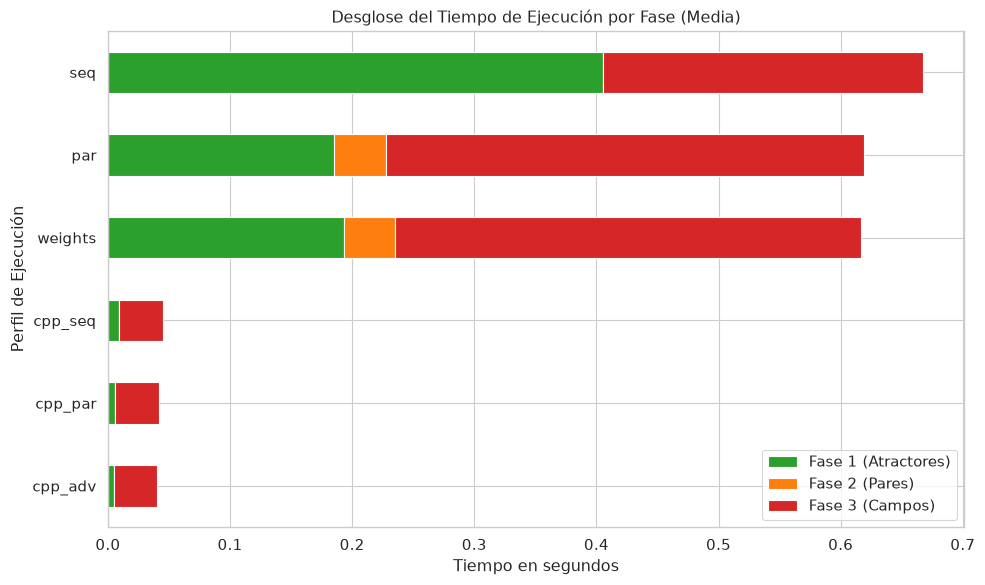

In [5]:
columnas_tiempo = ['t_p1', 't_p2', 't_p3', 'total_t']

# Agrupamos por perfil y calculamos la media
resumen_medias = df.groupby('perfil')[columnas_tiempo].mean().sort_values('total_t')

print("TIEMPO MEDIO DE EJECUCIÓN (Segundos)\n")
print(resumen_medias.round(6))

# Gráfico de Barras Apiladas (Composición del Tiempo)
ax = resumen_medias[['t_p1', 't_p2', 't_p3']].plot(
    kind='barh', stacked=True, color=['#2ca02c', '#ff7f0e', '#d62728'], figsize=(10, 6)
)
plt.title("Desglose del Tiempo de Ejecución por Fase (Media)")
plt.xlabel("Tiempo en segundos")
plt.ylabel("Perfil de Ejecución")
plt.legend(["Fase 1 (Atractores)", "Fase 2 (Pares)", "Fase 3 (Campos)"])
plt.tight_layout()
plt.show()

> **Insight del Analista:** 
> 1. **La tiranía de la Fase 3:** En Python, la Fase 3 consume la mayor parte del tiempo.
> 2. **El Overhead de la Fase 2:** Observa cómo `t_p2` en Python Secuencial (`seq`) es de ~0.0003s, pero al paralelizar (`par`, `weights`), salta a ~0.04s. El costo de crear hilos/procesos es 100 veces mayor que el cálculo real en esa fase. ¡La Fase 2 no debe paralelizarse en Python!
> 3. **Supremacía C++:** Los perfiles C++ aplastan a Python en la Fase 1 y Fase 3.

## 4. Análisis de Speedup (Aceleración)
Calculamos cuántas veces más rápido es cada perfil tomando como línea base a Python Secuencial (`seq`).

In [6]:
mean_seq_py = resumen_medias.loc['seq', 'total_t']

print("=" * 50)
print("SPEEDUP RESPECTO A PYTHON SECUENCIAL (Baseline)")
print("=" * 50)

for perfil in resumen_medias.index:
    if perfil == 'seq':
        continue
    tiempo_perfil = resumen_medias.loc[perfil, 'total_t']
    speedup = mean_seq_py / tiempo_perfil
    
    # Separar visualmente las ligas
    if "cpp" in perfil:
        print(f"🚀 {perfil.ljust(10)} : {speedup:.2f}x más rápido")
    else:
        print(f"⚡ {perfil.ljust(10)} : {speedup:.2f}x más rápido")

SPEEDUP RESPECTO A PYTHON SECUENCIAL (Baseline)
🚀 cpp_adv    : 16.74x más rápido
🚀 cpp_par    : 16.11x más rápido
🚀 cpp_seq    : 14.90x más rápido
⚡ weights    : 1.08x más rápido
⚡ par        : 1.08x más rápido


## 5. Panel Visual Avanzado (Distribución y Dispersión)
Debido a la enorme diferencia entre C++ y Python, graficarlos en la misma escala lineal oculta los detalles de C++. Usaremos una **escala logarítmica** y paneles separados.

/tmp/ipykernel_417684/2124797336.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='perfil', y='total_t', palette=colores_perfiles)



💾 Gráfico guardado para el paper en: 'results/advanced_benchmark_dashboard.png'


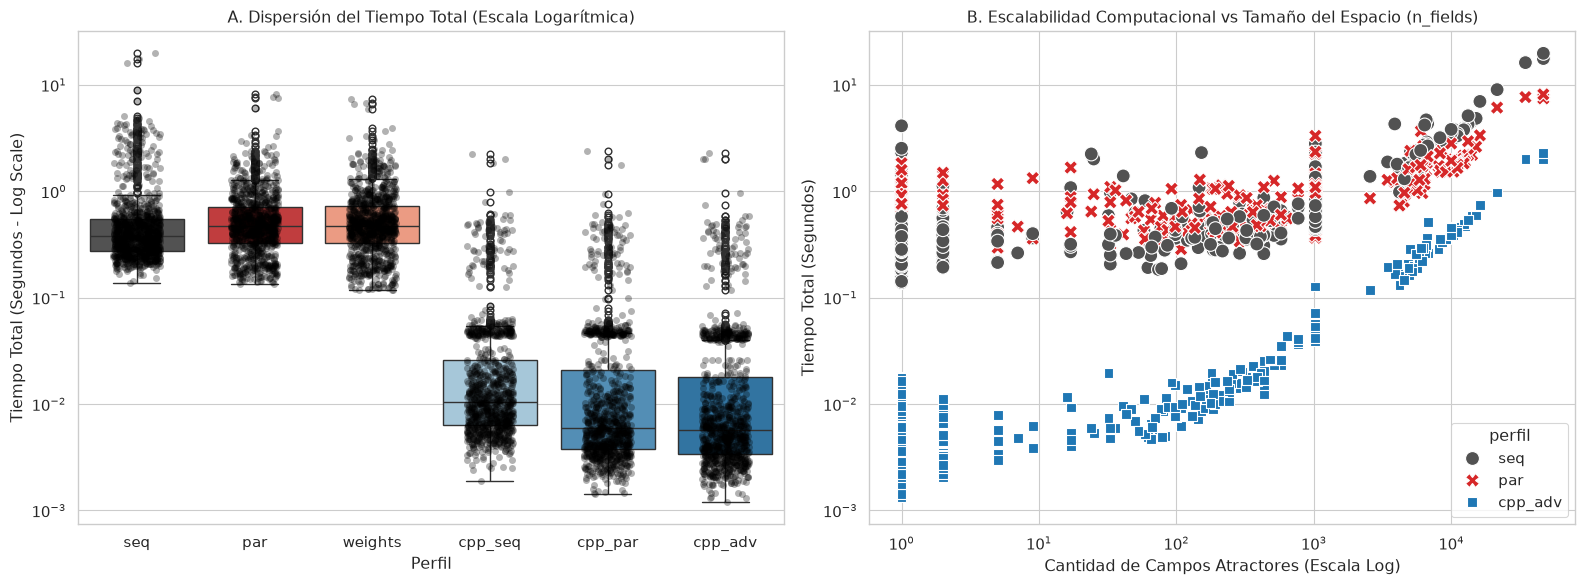

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: Dispersión Total (Escala Logarítmica)
sns.boxplot(ax=axes[0], data=df, x='perfil', y='total_t', palette=colores_perfiles)
sns.stripplot(ax=axes[0], data=df, x='perfil', y='total_t', color='black', alpha=0.3, jitter=0.2)
axes[0].set_yscale('log') # ESCALA LOGARÍTMICA CRÍTICA AQUÍ
axes[0].set_title("A. Dispersión del Tiempo Total (Escala Logarítmica)")
axes[0].set_ylabel("Tiempo Total (Segundos - Log Scale)")
axes[0].set_xlabel("Perfil")

# Panel B: Escalabilidad (Tiempo vs Complejidad del Espacio de Campos)
# Filtramos solo los perfiles más rápidos de cada lenguaje para ver la tendencia
df_filtrado = df[df['perfil'].isin(['seq', 'par', 'cpp_adv'])]
sns.scatterplot(ax=axes[1], data=df_filtrado, x='n_fields', y='total_t', hue='perfil', style='perfil', s=100, palette={'seq':'#525252', 'par':'#d62728', 'cpp_adv':'#1f77b4'})
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title("B. Escalabilidad Computacional vs Tamaño del Espacio (n_fields)")
axes[1].set_ylabel("Tiempo Total (Segundos)")
axes[1].set_xlabel("Cantidad de Campos Atractores (Escala Log)")

plt.tight_layout()
plt.savefig("results/advanced_benchmark_dashboard.png", dpi=300)
print("\n💾 Gráfico guardado para el paper en: 'results/advanced_benchmark_dashboard.png'")
plt.show()